# Power Analysis for LLM Evaluations

**O'Reilly Live Course**: *Statistical Testing for LLM Evaluations*  
**Subtitle**: *Design experiments that catch the improvements worth shipping*  
**Instructor**: Rudrendu Paul  
**Live Demo 1 of 2: Power analysis (7 min)**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RudrenduPaul/statistical-testing-for-llm-evaluations/blob/main/notebooks/01-power-analysis-llm-evals.ipynb)

---

## What this notebook covers

A team that compares two prompts on 50 examples and finds p > 0.05 has not shown the prompts perform equally. It has shown the experiment lacked the power to detect a difference.

- **Section 1**: a simulated 5-point improvement that 50 examples cannot detect and 847 examples can.
- **Section 2**: statistical power, and why 50 examples gives about 10%.
- **Section 3**: how many examples you need.

**All data is synthetic.** No API keys, no external files.

## Setup

Installs required libraries. Colab-safe, skips packages that are present.

Version conflict in Colab? Run **Runtime → Restart and run all** after the pip install cell.

In [1]:
try:
    import numpy, scipy, statsmodels, matplotlib
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy", "statsmodels", "matplotlib", "numpy", "--quiet"])

### Importing libraries

- NumPy: array math, random draws
- Matplotlib: plotting
- SciPy: the t-test
- statsmodels: `TTestIndPower`, an analytical power solver

Analytical solvers return the same answer as a 10,000-run simulation in microseconds, so we use them for the power curves.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# TTestIndPower: analytical power for two independent groups (unknown equal variance)
from statsmodels.stats.power import TTestIndPower
import warnings
warnings.filterwarnings('ignore')

# Global plot style: clean white background, readable fonts
# We set these once rather than repeating rcParams in every plot cell
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#cccccc',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2.0,
})

# Seed for reproducibility: every random draw in this notebook uses this seed,
# so students and instructors see the same numbers every run
np.random.seed(42)

print("Setup complete. NumPy:", np.__version__)

Setup complete. NumPy: 2.4.3


---

## Section 1: Why 50 Examples Is Not Enough

An underpowered eval doesn't save you from a bad decision. It disguises the bad decision as "no significant difference."

**The scenario**: two prompt versions for a RAG customer support system, scored on a 0–100 faithfulness scale. Fifty test cases per prompt. Result: p > 0.05, so the team concludes "no significant difference."

That conclusion is wrong. A non-significant p-value does **not** mean the null hypothesis is true. It means there wasn't enough evidence to reject it. Those are different statements.

Think of it like searching a dark room for your keys with a candle. Not finding them doesn't mean they're not there. It means the candle was too dim to see them. An underpowered experiment is a dim candle: the p-value tells you what it saw, nothing more.

### Generating synthetic LLM quality scores

The scores below are simulated, so we can set the truth and then check whether an experiment finds it.

- **The truth we set**: Prompt A has a true average faithfulness score of **72**. Prompt B has a true average of **77**. The true difference is 77 - 72 = **5 points**. Both prompts have the same true score SD of 36.7.
- **Noisy, ceiling-heavy scores**: a faithfulness judge often gives the maximum score of 100, sometimes a 0, and spreads the rest in between. The generator draws each score as a 100, a 0, or a value spread evenly between 0 and 100. The shares of each are solved so the true average and SD match the values above (Prompt A: 52% scores of 100, 8% zeros, 40% spread. Prompt B: 64% scores of 100, 10% zeros, 25% spread).

Ground truth: Prompt B is better by 5 points by construction. The question is whether 50 examples can detect it. The random seeds are fixed, and each experiment below shows one draw. A different seed gives a different measured gap, and at n=50 the gap swings widely (the next cell prints the range).

In [3]:
def mixture_shares(mean, std):
    """
    Shares of a 0-100 score distribution built from three parts: a share that scores 100,
    a share that scores 0, and a share spread evenly between 0 and 100.
    The shares are solved so the distribution has the requested mean and SD.
    """
    # mean       = 100*p_top + 50*p_spread
    # mean^2+sd^2 = 10000*p_top + (10000/3)*p_spread
    A = np.array([[100.0, 50.0], [10000.0, 10000.0 / 3]])
    y = np.array([mean, mean ** 2 + std ** 2])
    p_top, p_spread = np.linalg.solve(A, y)
    return p_top, 1 - p_top - p_spread, p_spread


def simulate_llm_scores(n, mean, std, seed):
    """Simulate n LLM faithfulness scores on a 0-100 scale with the given true mean and SD."""
    rng = np.random.default_rng(seed)
    p_top, p_zero, p_spread = mixture_shares(mean, std)
    u = rng.random(n)
    spread = rng.uniform(0, 100, n)
    return np.where(u < p_top, 100.0, np.where(u < p_top + p_zero, 0.0, spread))


# True population parameters: the ground truth, which we normally do NOT know.
# In a live experiment we are trying to ESTIMATE the difference from data.
# Here we set the truth so we can check whether the experiment finds it.
TRUE_MEAN_A = 72.0   # Prompt A: true average faithfulness score (0-100)
TRUE_MEAN_B = 77.0   # Prompt B: true average faithfulness score (0-100)
SCORE_STD   = 36.7   # True score SD for both prompts, a noisy 0-100 LLM-judge faithfulness score

print(f"Prompt A true average score: {TRUE_MEAN_A:.1f}")
print(f"Prompt B true average score: {TRUE_MEAN_B:.1f}")
print(f"True difference: {TRUE_MEAN_B:.1f} - {TRUE_MEAN_A:.1f} = {TRUE_MEAN_B - TRUE_MEAN_A:.1f} points")
print(f"True score SD (both prompts): {SCORE_STD}")
for _name, _mu in (("A", TRUE_MEAN_A), ("B", TRUE_MEAN_B)):
    _top, _zero, _spread = mixture_shares(_mu, SCORE_STD)
    print(f"Prompt {_name} score mix: {_top:.0%} score 100, {_zero:.0%} score 0, {_spread:.0%} spread between 0 and 100")
_se50 = SCORE_STD * np.sqrt(2 / 50)
print(f"At n=50 per prompt, the measured gap swings by about +/- {1.96 * _se50:.0f} points around the true 5 "
      f"(95% of experiments land between {5 - 1.96 * _se50:.0f} and {5 + 1.96 * _se50:.0f}).")
print()

# Small experiment: 50 examples per prompt (this is what most teams run)
n_small = 50
scores_A_small = simulate_llm_scores(n_small, TRUE_MEAN_A, SCORE_STD, seed=17)
scores_B_small = simulate_llm_scores(n_small, TRUE_MEAN_B, SCORE_STD, seed=1017)

print(f"=== Small experiment (n={n_small} per prompt) ===")
print(f"Prompt A sample mean: {scores_A_small.mean():.2f}  (true {TRUE_MEAN_A:.0f})")
print(f"Prompt B sample mean: {scores_B_small.mean():.2f}  (true {TRUE_MEAN_B:.0f})")
print(f"Measured gap: {scores_B_small.mean():.2f} - {scores_A_small.mean():.2f} = "
      f"{scores_B_small.mean() - scores_A_small.mean():.2f} points  (true gap {TRUE_MEAN_B - TRUE_MEAN_A:.0f})")
print()

# Two-sample independent t-test.
# Why independent? Each test case goes to one prompt version, not both.
# For paired designs (same test case scored by both prompts), use stats.ttest_rel instead.
t_stat, p_value = stats.ttest_ind(scores_B_small, scores_A_small)
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.3f}")
print()

if p_value < 0.05:
    print("Result: SIGNIFICANT (p < 0.05)")
else:
    print(f"Result: NOT SIGNIFICANT (p = {p_value:.3f} > 0.05)")
    print()
    print("Common (wrong) interpretation: 'The prompts perform the same.'")
    print("Correct interpretation: 'This experiment did not have enough power")
    print("  to detect the difference reliably. We need more data.'")

Prompt A true average score: 72.0
Prompt B true average score: 77.0
True difference: 77.0 - 72.0 = 5.0 points
True score SD (both prompts): 36.7
Prompt A score mix: 52% score 100, 8% score 0, 40% spread between 0 and 100
Prompt B score mix: 64% score 100, 10% score 0, 25% spread between 0 and 100
At n=50 per prompt, the measured gap swings by about +/- 14 points around the true 5 (95% of experiments land between -9 and 19).

=== Small experiment (n=50 per prompt) ===
Prompt A sample mean: 70.63  (true 72)
Prompt B sample mean: 75.99  (true 77)
Measured gap: 75.99 - 70.63 = 5.36 points  (true gap 5)

t-statistic: 0.700
p-value:     0.485

Result: NOT SIGNIFICANT (p = 0.485 > 0.05)

Common (wrong) interpretation: 'The prompts perform the same.'
Correct interpretation: 'This experiment did not have enough power
  to detect the difference reliably. We need more data.'


**KEY INSIGHT: What a non-significant p means**

- p > 0.05 means: if the null hypothesis were true, a result this extreme would not be unusual by chance
- It does NOT mean the null hypothesis is true, and it does NOT mean there is no difference
- It means the 50-example signal was too faint to clear the threshold
- The p-value is a statement about the data given the null hypothesis, not about the null hypothesis given the data

Correct read: "This experiment was not large enough to detect a 5-point difference reliably."

### Visualizing the score distributions

Both panels draw from the same truth: Prompt A averages 72, Prompt B averages 77, a 5-point difference. The dotted grey lines mark those true averages. The dashed colored lines mark each experiment's sample means.

- **Left panel (n=50)**: the measured gap is 75.99 - 70.63 = 5.36 points, close to the true 5. The noise is so large that a gap this size is still not distinguishable from chance (p = 0.485).
- **Right panel (n=847)**: the measured gap is 77.39 - 72.45 = 4.94 points. The same 5-point difference now clears the significance line (p = 0.0054).

Only the sample size changed, and that changed the conclusion.

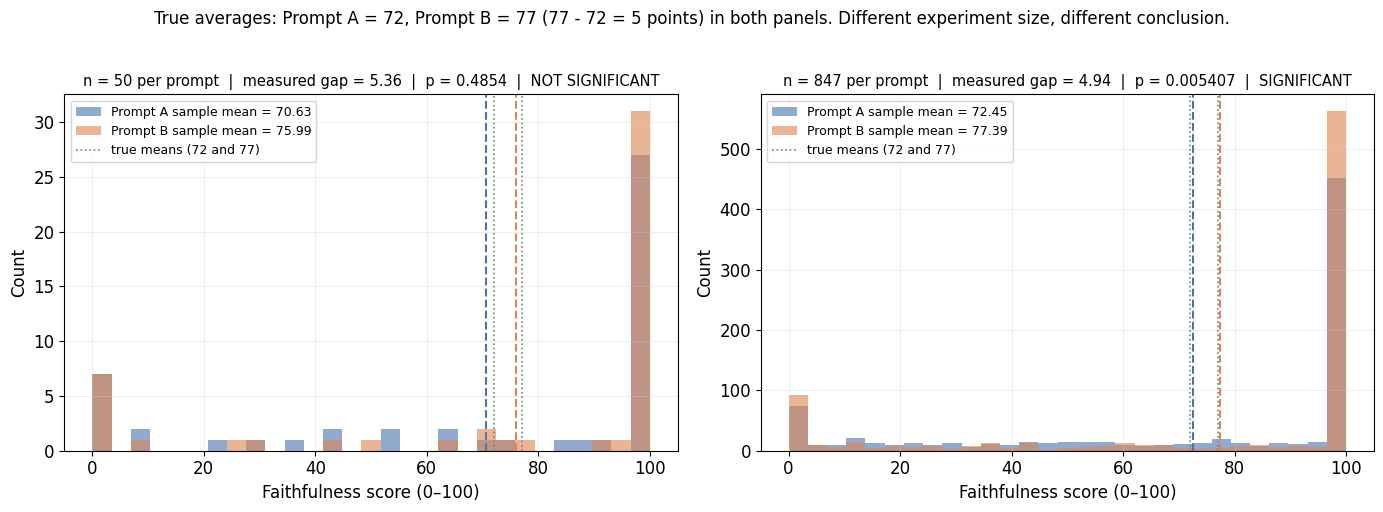

True averages: Prompt A 72, Prompt B 77. True difference: 77 - 72 = 5 points, in both panels.
n=50: measured gap = 75.99 - 70.63 = 5.36 points, p = 0.485  -> inconclusive
n=847: measured gap = 77.39 - 72.45 = 4.94 points, p = 0.0054  -> significant


In [4]:
# Two panels side by side make the core argument visual.
# Left panel: n=50 (common practice). The true gap is 5 points, but the noise swamps it.
# Right panel: n=847 (required for this effect size). The same true gap now shows up in the test.
# Both panels use the same true averages (A = 72, B = 77). Only the sample size changes.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.linspace(0, 100, 30)

# Large experiment: 847 examples per prompt
n_large = 847
scores_A_large = simulate_llm_scores(n_large, TRUE_MEAN_A, SCORE_STD, seed=2)
scores_B_large = simulate_llm_scores(n_large, TRUE_MEAN_B, SCORE_STD, seed=1002)
_, p_large = stats.ttest_ind(scores_B_large, scores_A_large)

panels = [
    (axes[0], n_small, scores_A_small, scores_B_small, p_value, "NOT SIGNIFICANT"),
    (axes[1], n_large, scores_A_large, scores_B_large, p_large, "SIGNIFICANT"),
]
for ax, n, sa, sb, p, verdict in panels:
    # Semi-transparent histograms (alpha=0.6) so the overlap region is visible
    ax.hist(sa, bins=bins, alpha=0.6, color='#4C72B0', label=f'Prompt A sample mean = {sa.mean():.2f}')
    ax.hist(sb, bins=bins, alpha=0.6, color='#DD8452', label=f'Prompt B sample mean = {sb.mean():.2f}')
    # Dashed lines: sample means. Dotted grey lines: the true means we set (72 and 77).
    ax.axvline(sa.mean(), color='#4C72B0', linestyle='--', linewidth=1.5)
    ax.axvline(sb.mean(), color='#DD8452', linestyle='--', linewidth=1.5)
    ax.axvline(TRUE_MEAN_A, color='grey', linestyle=':', linewidth=1.2)
    ax.axvline(TRUE_MEAN_B, color='grey', linestyle=':', linewidth=1.2, label='true means (72 and 77)')
    ax.set_xlabel('Faithfulness score (0–100)')
    ax.set_ylabel('Count')
    ax.set_title(f'n = {n} per prompt  |  measured gap = {sb.mean() - sa.mean():.2f}  |  p = {p:.4g}  |  {verdict}', fontsize=10.5)
    ax.legend(loc='upper left', fontsize=9)

fig.suptitle('True averages: Prompt A = 72, Prompt B = 77 (77 - 72 = 5 points) in both panels. Different experiment size, different conclusion.',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f"True averages: Prompt A {TRUE_MEAN_A:.0f}, Prompt B {TRUE_MEAN_B:.0f}. True difference: {TRUE_MEAN_B:.0f} - {TRUE_MEAN_A:.0f} = {TRUE_MEAN_B - TRUE_MEAN_A:.0f} points, in both panels.")
print(f"n={n_small}: measured gap = {scores_B_small.mean():.2f} - {scores_A_small.mean():.2f} = {scores_B_small.mean() - scores_A_small.mean():.2f} points, p = {p_value:.3f}  -> inconclusive")
print(f"n={n_large}: measured gap = {scores_B_large.mean():.2f} - {scores_A_large.mean():.2f} = {scores_B_large.mean() - scores_A_large.mean():.2f} points, p = {p_large:.4f}  -> significant")

**KEY INSIGHT: The same simulated difference, two different stories**

Both experiments measure about the true 5-point gap (5.36 at n=50, 4.94 at n=847). With 50 examples per prompt the noise swamps that gap (p = 0.485). With 847 examples the same gap is clear (p = 0.0054). Only the sample size changed, and the conclusion flipped from "not significant" to "significant". Statistical significance isn't a property of the effect alone. It's a joint property of the effect and the experimental design. An underpowered experiment can't reliably detect a difference of this size, however carefully it is run.

---

## Section 2: Understanding Statistical Power

Power quantifies the probability your experiment can back a claim like "Prompt B scored higher." Most practitioners never calculate the power of their eval setup.

---

**Statistical power** is like camera resolution. A 50-example eval is a blurry photo: you might see something, but you can't tell if it's an object or noise. An 847-example eval is high-resolution: you can confidently identify true differences.

Formally: **Power = P(reject H₀ | H₁ is true)**

Standard target: **80% power** (an 80% chance of detecting the effect if it exists). Below 80% power is like a smoke detector that fires only 40% of the time during a fire.

Four variables. Fix any three and the fourth is determined:

| Variable | Symbol | What it controls |
|---|---|---|
| Effect size | δ | Size of the true difference relative to noise |
| Sample size | n | Observations per condition |
| Significance level | α | Type I error rate (usually 0.05) |
| Power | 1 − β | Probability of detecting the effect (β = Type II error rate) |

In practice, α is fixed at 0.05 and power at 0.80 or higher. That leaves effect size and sample size to negotiate: if the budget only allows n=100, you either accept lower power or accept that only larger improvements are detectable. **Effect size comes from domain knowledge** of what improvement matters.

### Calculating the power of the 50-example experiment

Cohen's d, the standardized effect size for a t-test: **d = (mean_B - mean_A) / pooled_std**. Standardizing by the pooled standard deviation makes effect sizes comparable across scales, so a 5-point gain on 0–100 and a 0.5-point gain on 1–5 can share the same d.

**Cohen's d benchmarks for LLM evaluation:**

- **d = 0.20 (small)**: ≈7 points on 0–100. Raters would argue about it. Needs ≈393 examples per group.
- **d = 0.50 (medium)**: ≈18 points. Most raters agree it's better. Needs ≈64 examples per group.
- **d = 0.80 (large)**: ≈29 points, obvious. Needs only ≈26 examples per group, and is rare once a system is tuned.

Our scenario sits at d ≈ 0.14 (5 points over an SD of 36.7), below "small," the realistic range when comparing two tuned prompts.

In [5]:
# Cohen's d: standardized effect size
# d = (mean_B - mean_A) / pooled_std
# We divide by the pooled std (not just one group's std) to get a scale-free measure.
# This allows comparison across metrics with different units and ranges.
true_difference = TRUE_MEAN_B - TRUE_MEAN_A   # 5 points: this is the RAW effect size
cohens_d = true_difference / SCORE_STD        # this is the STANDARDIZED effect size

print(f"True mean difference: {true_difference:.2f} points")
print(f"True score standard deviation: {SCORE_STD:.2f}")
print(f"Cohen's d (effect size): {cohens_d:.4f}")
print()
print("Cohen's d benchmarks:")
print("  Small effect:  d = 0.20  (subtle; human raters would disagree)")
print("  Medium effect: d = 0.50  (noticeable; most raters agree it's better)")
print("  Large effect:  d = 0.80  (obvious; everyone can see it)")
print(f"\nOur effect (d={cohens_d:.2f}) is classified as: ", end="")
if cohens_d < 0.20:
    print("below small")
elif cohens_d < 0.50:
    print("small")
elif cohens_d < 0.80:
    print("medium")
else:
    print("large")

print()

# We use TTestIndPower rather than NormalIndPower because:
# - Our scenario compares TWO INDEPENDENT groups (Prompt A vs Prompt B)
# - We do NOT know the true population variance: we estimate it from data
# - For PAIRED data (same test case scored by both prompts), we would use TTestPower instead
# - NormalIndPower assumes known variance, which is almost never the case in practice
analysis = TTestIndPower()
power_50 = analysis.solve_power(
    effect_size=cohens_d,
    nobs1=n_small,        # n per group (we have 50 in each condition)
    alpha=0.05,           # Type I error rate (the "false positive" threshold)
    alternative='two-sided'  # we care about improvement in either direction
)

print(f"Power of the n={n_small} experiment: {power_50:.1%}")
print()
print(f"Interpretation: that experiment had only a {power_50:.0%} chance of detecting")
print(f"the 5-point improvement. It was nearly guaranteed to miss it.")
print(f"The probability of a false negative (Type II error): {1 - power_50:.1%}")
print()
power_sd12 = analysis.solve_power(effect_size=true_difference / 12.0, nobs1=n_small, alpha=0.05, alternative='two-sided')
print(f"The {power_50:.0%} holds for the noise level in this simulation (SD about {SCORE_STD:.0f}).")
print(f"With a tighter metric (SD 12) the same 5-point gain at n={n_small} has {power_sd12:.0%} power.")

True mean difference: 5.00 points
True score standard deviation: 36.70
Cohen's d (effect size): 0.1362

Cohen's d benchmarks:
  Small effect:  d = 0.20  (subtle; human raters would disagree)
  Medium effect: d = 0.50  (noticeable; most raters agree it's better)
  Large effect:  d = 0.80  (obvious; everyone can see it)

Our effect (d=0.14) is classified as: below small

Power of the n=50 experiment: 10.4%

Interpretation: that experiment had only a 10% chance of detecting
the 5-point improvement. It was nearly guaranteed to miss it.
The probability of a false negative (Type II error): 89.6%

The 10% holds for the noise level in this simulation (SD about 37).
With a tighter metric (SD 12) the same 5-point gain at n=50 has 54% power.


**KEY INSIGHT: Power = 10% means the experiment was nearly pointless**

- A 10%-powered experiment has a ≈90% chance of missing an improvement that exists
- Run it 10 times: roughly 1 significant result, 9 non-significant
- The 10% holds for the noise level in this simulation (SD about 37). With a tighter metric (SD 12), the same 5-point gain at n=50 has about 54% power
- Teams that read "not significant" as "no improvement" throw away a better prompt 90% of the time

A Type I error (false positive) ships a change that doesn't help. A Type II error (false negative) discards a change that does help, and in LLM product development, Type II errors can be costly.

### Visualizing the power curve

Power rises with sample size, and the rate depends on effect size: large effects need fewer examples, small effects need many more. For small effects the curve stays low below n=100 and keeps climbing past n=800. The medium effect (d=0.50) reaches 94% power by n=100.

Doubling the sample from 50 to 100 moves power for our scenario from 10% to only 16%. Reaching 80% power for a small effect can take an increase of about 8x in n (50 to 393 per group for d=0.20), not 2x.

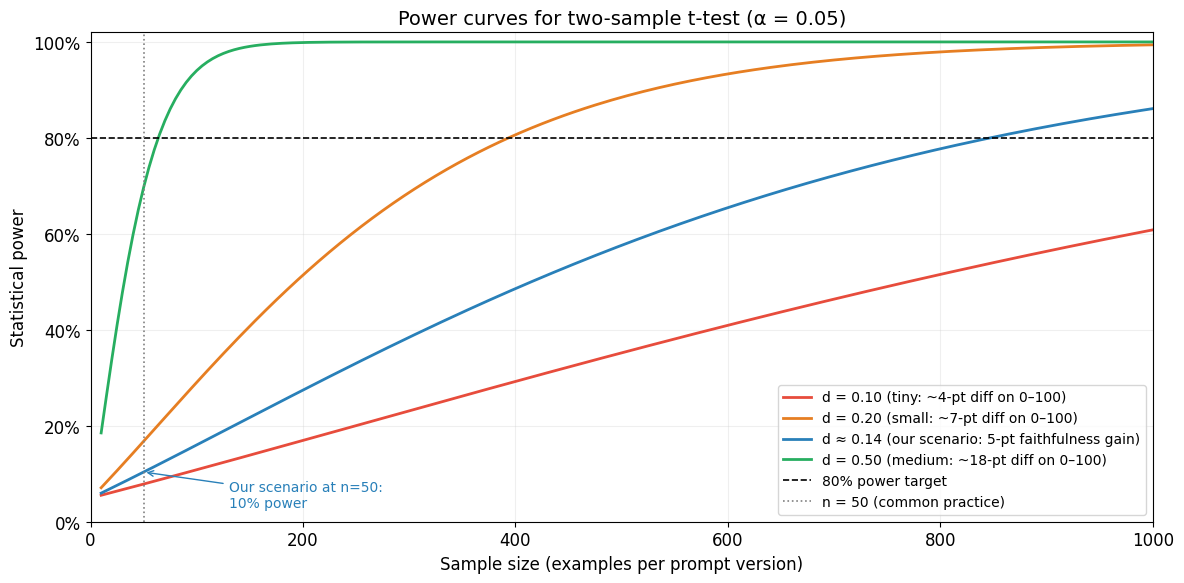


Key insight: at n=50, even a medium effect (d=0.50) achieves only ~70% power.
For the small effects typical in prompt comparisons, you need hundreds of examples.


In [6]:
# We sweep sample sizes from 10 to 1000 in steps of 5 to get a smooth curve.
# Using steps of 1 would be more precise but produces an imperceptibly smoother line.
# Steps of 5 keep computation fast while preserving visual resolution.
sample_sizes = np.arange(10, 1001, 5)

# We show four effect sizes representing the realistic range in LLM evaluation:
# d=0.10 (tiny: essentially undetectable in practice without thousands of examples)
# d=0.20 (small: prompt tuning gains; human raters often disagree)
# d≈0.14 (our scenario: 5-pt faithfulness gain on 0-100 with std≈37)
# d=0.50 (medium: noticeable improvement; most raters agree)
effect_sizes = {
    'd = 0.10 (tiny: ~4-pt diff on 0–100)': 0.10,
    'd = 0.20 (small: ~7-pt diff on 0–100)': 0.20,
    'd ≈ 0.14 (our scenario: 5-pt faithfulness gain)': cohens_d,
    'd = 0.50 (medium: ~18-pt diff on 0–100)': 0.50,
}

# Red to green gradient signals "more detectable" as we move down the legend
colors = ['#e74c3c', '#e67e22', '#2980b9', '#27ae60']

fig, ax = plt.subplots(figsize=(12, 6))

# We re-instantiate TTestIndPower here (rather than reusing the one from above) to
# make this cell self-contained and runnable even if cells above were skipped
analysis = TTestIndPower()

for (label, d), color in zip(effect_sizes.items(), colors):
    # For each effect size, compute the power at every sample size.
    # solve_power with nobs1 specified (and power=None) returns the power value.
    powers = [analysis.solve_power(effect_size=d, nobs1=n, alpha=0.05, alternative='two-sided')
              for n in sample_sizes]
    # The solver returns NaN once power rounds to 1.0, which would leave gaps in the line
    powers = np.nan_to_num(powers, nan=1.0)
    ax.plot(sample_sizes, powers, label=label, color=color)

# The 80% reference line is the standard target. Below this line, experiments
# are considered underpowered for professional research purposes
ax.axhline(0.80, color='black', linestyle='--', linewidth=1.2, label='80% power target')

# n=50 reference: this is what most teams run. Notice it is far below 80% for
# all but the largest effect sizes.
ax.axvline(50, color='gray', linestyle=':', linewidth=1.2, label='n = 50 (common practice)')

ax.set_xlabel('Sample size (examples per prompt version)')
ax.set_ylabel('Statistical power')
ax.set_title('Power curves for two-sample t-test (α = 0.05)')
ax.set_ylim(0, 1.02)
ax.set_xlim(0, 1000)
# Format y-axis as percentages to make the 80% target immediately readable
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(loc='lower right', fontsize=10)

# Arrow annotation marking where our scenario falls at n=50
ax.annotate(
    f'Our scenario at n=50:\n{power_50:.0%} power',
    xy=(50, power_50),
    xytext=(130, 0.03),
    arrowprops=dict(arrowstyle='->', color='#2980b9'),
    color='#2980b9',
    fontsize=10
)

plt.tight_layout()
plt.show()

print("\nKey insight: at n=50, even a medium effect (d=0.50) achieves only ~70% power.")
print("For the small effects typical in prompt comparisons, you need hundreds of examples.")

**KEY INSIGHT: The curve is flat where teams operate**

At n=50:
- d=0.10 (tiny): power below 10%
- d=0.20 (small): power ≈17%
- d≈0.14 (our scenario, SD about 37): power ≈10%, nine misses out of ten
- d=0.50 (medium): power only ≈70%

Most teams run evals in the n=20 to n=100 range, right where the curves for small effects sit near the floor. Only large, obvious improvements are detectable there.

---

## Section 3: How Many Examples Do You Need?

Flip the question: given 80% power and a minimum improvement that matters, how many examples do you need?

**Our example**: detect a 5-point faithfulness improvement on a 0–100 scale (std ≈ 37, d ≈ 0.14), at 80% power, α = 0.05.

**Required n = 847, not 50.**

**Cost check**: at 0.10 USD per API call, 847 examples per prompt costs 85 USD per arm (169 USD for both arms, more if you pay for a judge call per response), against the cost of shipping a prompt regression at scale.

The minimum meaningful improvement is a product decision, not a statistical one. If faithfulness goes from 65 to 66, most teams wouldn't ship it. From 65 to 70, most would. Statistics tells you how many examples you need once you decide what counts as meaningful.

### Required sample size by improvement

As the improvement you want to detect halves, the required n roughly quadruples. Detecting a 3-point improvement instead of a 5-point one needs nearly 3x the data.

In [7]:
analysis = TTestIndPower()

def required_n(effect_size_d, alpha=0.05, power=0.80):
    """Required n per group for a two-sample t-test, rounded up."""
    n = analysis.solve_power(effect_size=effect_size_d, alpha=alpha, power=power, alternative='two-sided')
    return int(np.ceil(n))

print(f"Faithfulness on a 0-100 scale (true SD {SCORE_STD}), 80% power, alpha = 0.05")
for diff in [3, 5, 10, 15, 20]:
    d = diff / SCORE_STD
    marker = "   <-- our 5-point gain" if diff == 5 else ""
    print(f"  Detect a {diff:>2}-point improvement (d={d:.2f}) -> n = {required_n(d):>5} per prompt{marker}")

n_needed = required_n((TRUE_MEAN_B - TRUE_MEAN_A) / SCORE_STD)
print()
print(f"To detect our 5-point gain: n = {n_needed} per prompt, against {n_small} in the small experiment ({n_needed / n_small:.0f} times more).")

Faithfulness on a 0-100 scale (true SD 36.7), 80% power, alpha = 0.05
  Detect a  3-point improvement (d=0.08) -> n =  2351 per prompt
  Detect a  5-point improvement (d=0.14) -> n =   847 per prompt   <-- our 5-point gain
  Detect a 10-point improvement (d=0.27) -> n =   213 per prompt
  Detect a 15-point improvement (d=0.41) -> n =    95 per prompt
  Detect a 20-point improvement (d=0.54) -> n =    54 per prompt

To detect our 5-point gain: n = 847 per prompt, against 50 in the small experiment (17 times more).


**KEY INSIGHT: n = 847 is the number that should change your eval policy**

- 847 per prompt (1,694 total) vs the 50 most teams run: 17x larger
- An underpowered "not significant" result may have discarded a better prompt
- Cost: 1,694 examples at 0.10 USD/call = 169.40 USD, double if you pay for a judge call per response

The financial barrier to properly powered evals is lower than the organizational barrier. The problem is habit, not cost.

---

## Takeaway

- With scores this noisy (SD about 37), 50 examples give about 10% power for a 5-point gain. Run that experiment ten times and you catch the improvement about once.
- Catching it takes 847 examples per prompt, about 17 times more. At ten cents a call that is under 200 USD for both arms.
- The smallest improvement worth shipping is a product decision. Size the sample from it before you collect data, and do not add data after you see p = 0.08.

*This notebook accompanies the O'Reilly Live Course: **Statistical Testing for LLM Evaluations**, by Rudrendu Paul. All data is simulated.*